In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
data = {
    'order_value':  [500, 1200, 800, 3500, 200, 
                     4500, 900, 2800, 150, 5000,
                     600, 3200, 1800, 750, 4200],
    'delivery_days':[3, 5, 2, 7, 1, 
                     8, 3, 6, 2, 9,
                     4, 7, 5, 3, 8],
    'completed':    [1, 1, 1, 0, 1, 
                     0, 1, 0, 1, 0,
                     1, 0, 1, 1, 0]
}
df = pd.DataFrame(data)
print(df)

    order_value  delivery_days  completed
0           500              3          1
1          1200              5          1
2           800              2          1
3          3500              7          0
4           200              1          1
5          4500              8          0
6           900              3          1
7          2800              6          0
8           150              2          1
9          5000              9          0
10          600              4          1
11         3200              7          0
12         1800              5          1
13          750              3          1
14         4200              8          0


In [4]:
X = df[['order_value', 'delivery_days']]
y = df['completed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state =42)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (12, 2)
Test set size: (3, 2)


In [6]:
model = LogisticRegression()
model.fit(X_train,y_train)
print("Model train ho gaya")


Model train ho gaya


In [8]:
y_pred = model.predict(X_test)

print("Actual : ", y_test.values)
print("Predicted : ", y_pred)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy : {accuracy * 100:.1f}%")

Actual :  [0 0 1]
Predicted :  [0 0 1]

Accuracy : 100.0%


In [15]:
naya_order = pd.DataFrame({
    'order_value': [3000],
    'delivery_days': [7]
})

prediction = model.predict(naya_order)
print("Naya order ka prediction:", prediction)

if prediction[0] == 1:
    print("Order complete hoga ✅")
else:
    print("Order cancel hoga ❌")

naya_order2 = pd.DataFrame({
    'order_value': [500],
    'delivery_days': [2]
})
    
prediction2 = model.predict(naya_order2)
print("Naya order 2 ka prediction:", prediction2)

if prediction2[0] == 1:
    print("Order complete hoga ✅")
else:
    print("Order cancel hoga ❌")

Naya order ka prediction: [0]
Order cancel hoga ❌
Naya order 2 ka prediction: [1]
Order complete hoga ✅


In [9]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2 0]
 [0 1]]


Model Accuracy: 80.0%
Confusion Matrix (Raw Numbers):
[[4 1]
 [1 4]]


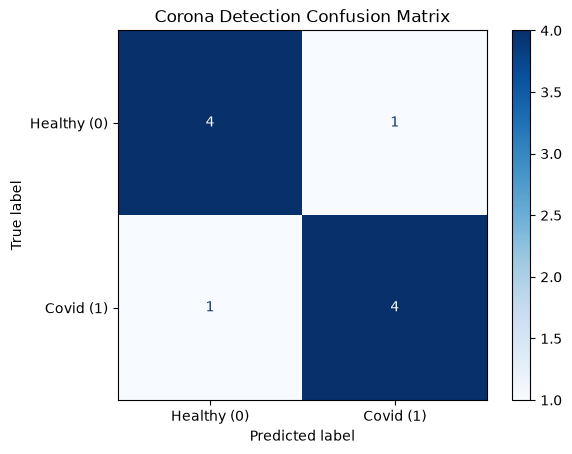

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay    

# Step 1: Real Data aur Model ki Predictions taiyar karna
# 1 = Corona Positive, 0 = Corona Negative (Healthy)

# Asal mein logon ko kya tha (Actual / Ground Truth)
y_actual =    [1, 1, 0, 1, 0, 0, 1, 0, 1, 0]

# Hamare model ne kya andaza lagaya (Predicted)
y_predicted = [1, 1, 1, 0, 0, 0, 1, 0, 1, 0]

accuracy = accuracy_score(y_actual, y_predicted)
print(f"Model Accuracy: {accuracy * 100:.1f}%")

# Step 2: Confusion Matrix generate karna
cm = confusion_matrix(y_actual, y_predicted)

# Step 3: Matrix ko asaan shakal mein print karna
print("Confusion Matrix (Raw Numbers):")
print(cm)


# Step 4: Isko visual format (Table/Graph) mein plot karna
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy (0)', 'Covid (1)'])
disp.plot(cmap=plt.cm.Blues)

# Plot ko show karna
plt.title("Corona Detection Confusion Matrix")
plt.show()